In [81]:
%load_ext autoreload
%autoreload 2

import numpy as np
import json
import matplotlib.pyplot as plt
import os
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Resultados parte A

In [82]:
with open("resultados/parteA.json") as f:
    data_A = json.load(f)

A_a = np.array(data_A["A_a"])
B_a = np.array(data_A["B_a"])
E_a = np.array(data_A["E_a"])
T = np.array(data_A["T"])
psi_ref = np.array(data_A["psi_ref"])

v_A = np.array(data_A["v"])
r_A = np.array(data_A["r"])
psi_A = np.array(data_A["psi"])
xi_A = np.array(data_A["xi"])

error_A = np.array(data_A["error"])
tau_A = np.array(data_A["tau_r"])

metrics_A = data_A["metrics"]

result_A = {
    "name": "PARTE A",
    "T": T,
    "psi_ref": psi_ref,
    "v": v_A,
    "r_yaw": r_A,
    "psi": psi_A,
    "xi": xi_A,
    "error": error_A,
    "tau_r": tau_A,
    "metrics": {
        "name": "PARTE A",
        "max_abs_tau": metrics_A["max_abs_tau"],
        "rms_tau": metrics_A["rms_tau"],
        "max_abs_error": metrics_A["max_abs_error"],
        "iae": metrics_A["iae"],
        "ise": metrics_A["ise"],
        "final_error": metrics_A["final_error"],
        "max_abs_v": metrics_A["max_abs_v"],
        "max_abs_r": metrics_A["max_abs_r"],
        "max_abs_psi": metrics_A["max_abs_psi"]
    }
}

### Resultadosd parte B

In [83]:
with open("resultados/parteB.json") as f:
    data_B = json.load(f)

X_B = np.array(data_B["X"])
Y_B = np.array(data_B["Y"])

### 1)

Partimos del sistema aumentado de la parte A con un integrador para poder seguir una referencia $\psi_{ref}$:

\begin{align*}
  \dot{\mathbf{x}}_a &= \mathbf{A}_a\mathbf{x}_a + \mathbf{B}_a\tau_r + \mathbf{E}_a\psi_{ref}
\end{align*}

Donde:


$$\mathbf{A}_a = \begin{bmatrix}
  -0.25 & -2 & 0 & 0 \\
  0.08 & -0.35 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & -1 & 0
\end{bmatrix}, \quad
\mathbf{B}_a = \begin{bmatrix} 0 \\ 0.62 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{E}_a = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix} $$



Para el diseño LQI, se busca una ley de control de la forma:

$$
\tau_{r}=-K_{a}x_{a}
$$

con:

$$
K_a=
\begin{bmatrix}
k_v & k_r & k_\psi & k_i
\end{bmatrix}
$$

Por lo tanto:

$$
\tau_r= -k_v v - k_r r - k_\psi \psi - k_i \xi
$$

El objetivo del diseño LQI es encontrar la ganancia $K_a$ que minimice la siguiente función de costo cuadrática:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + \tau_r^T R \tau_r \right)dt
$$

Como el sistema tiene una única entrada, $\tau_r$ es escalar, por lo que la función de costo también puede escribirse como:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + R\tau_r^2 \right)dt
$$

La matriz $Q_a$ penaliza los estados aumentados del sistema, mientras que $R$ penaliza el esfuerzo de control. Los pesos asociados a $\psi$ y a $xi$ permiten regular la precisión del seguimiento de rumbo y la eliminación del error estacionario, mientras que el valor de $R$ permite limitar la magnitud de la señal de control $\tau_r$.

Una elección posible para $Q_a$, si se trabaja con una matriz diagonal, es:

$$
Q_a=
\begin{bmatrix}
q_v & 0 & 0 & 0\\
0 & q_r & 0 & 0\\
0 & 0 & q_\psi & 0\\
0 & 0 & 0 & q_\xi
\end{bmatrix}
$$

y:

$$
R=
\begin{bmatrix}
r_u
\end{bmatrix}
$$


### 2)

Como se demostro en el ejercicio 4 de la parte A, al calcular el rango de la matriz de controlabilidad del sistema aumentado se obtiene rango completo. Por lo tanto, el sistema aumentado es controlable.

En este caso, esto permite concluir que es posible diseñar un controlador LQI para el sistema aumentado, ya que la acción de control $\tau_r$ puede influir sobre todos los estados del modelo aumentado, incluyendo el estado integral $xi$. La incorporación del integrador permite eliminar el error estacionario frente a referencias constantes de rumbo.

### Diseño de controlador LQI

In [84]:
from src.parteC import LQI, get_info, plot_results, print_metrics, plot_poles

In [ ]:
casos = {
    "AGRESIVO": {
        "Q_a": np.diag([1, 1, 50, 100]),
        "R": np.array([[1]])
    },
    "INTERMEDIO": {
        "Q_a": np.diag([1, 2, 30, 80]),
        "R": np.array([[10]])
    },
    "SUAVE": {
        "Q_a": np.diag([1, 5, 20, 50]),
        "R": np.array([[50]])
    }
}

Tf = 60

x0 = np.zeros(4)

controllers = {}
results = {}

for name, params in casos.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    controller = LQI(params["Q_a"], params["R"], A_a, B_a, E_a, verbose=True)
    result = get_info(name, controller, T, psi_ref, x0)

    controllers[name] = controller
    results[name] = result


AGRESIVO
K_a = [[  0.11013662   6.1203464   13.6645729  -10.        ]]
Polos LQI = [-1.43000924+1.66619895j -1.43000924-1.66619895j -1.28425664+0.j
 -0.25033966+0.j        ]

INTERMEDIO
K_a = [[ 0.1206056   3.46619819  5.11688483 -2.82842712]]
Polos LQI = [-0.7219319 +1.06663821j -0.7219319 -1.06663821j -0.25059663+0.j
 -1.05458244+0.j        ]

SUAVE
K_a = [[ 0.11968432  2.18981755  2.46134807 -1.        ]]
Polos LQI = [-0.47686276+0.76813255j -0.47686276-0.76813255j -0.25225098+0.j
 -0.75171037+0.j        ]


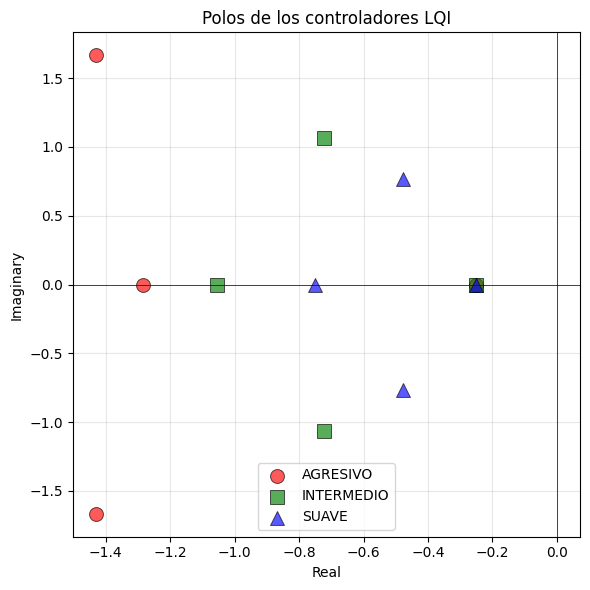

In [86]:
plot_poles(controllers, save=True, save_dir='plots')

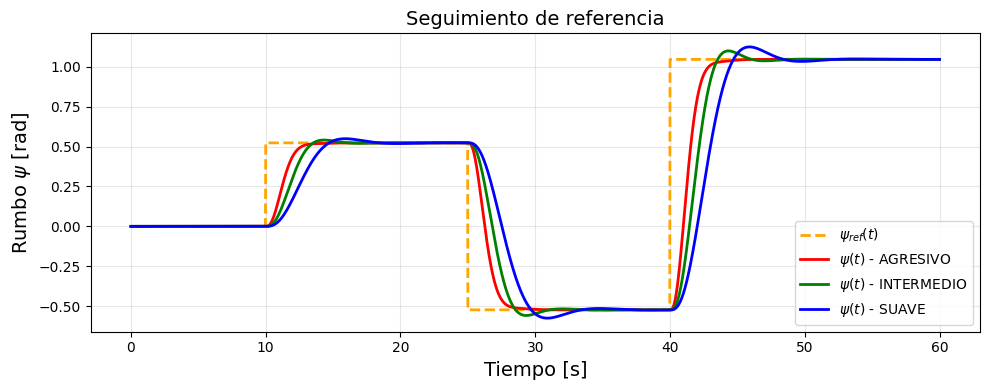

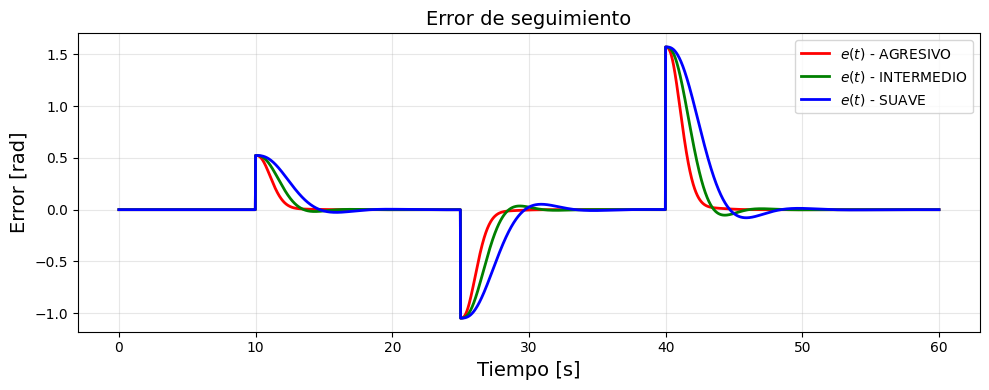

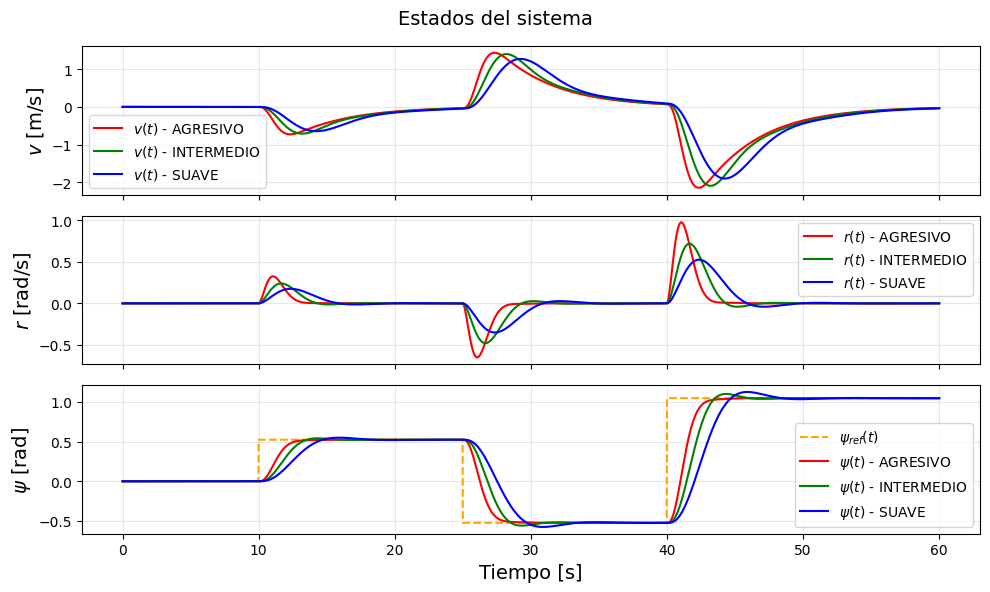

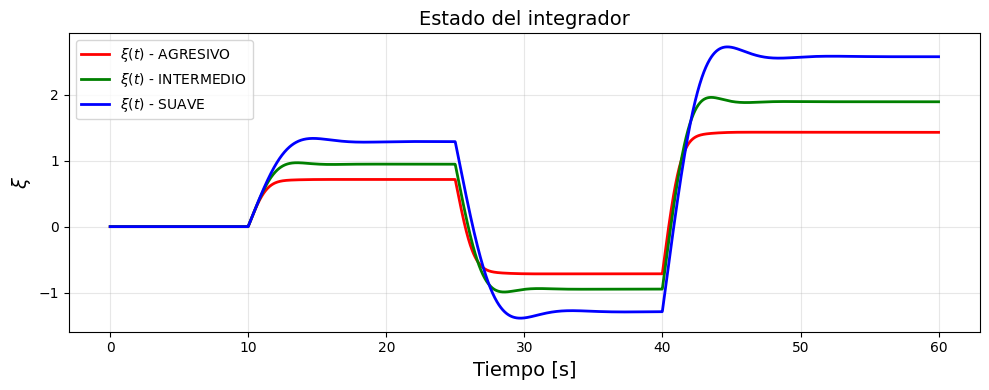

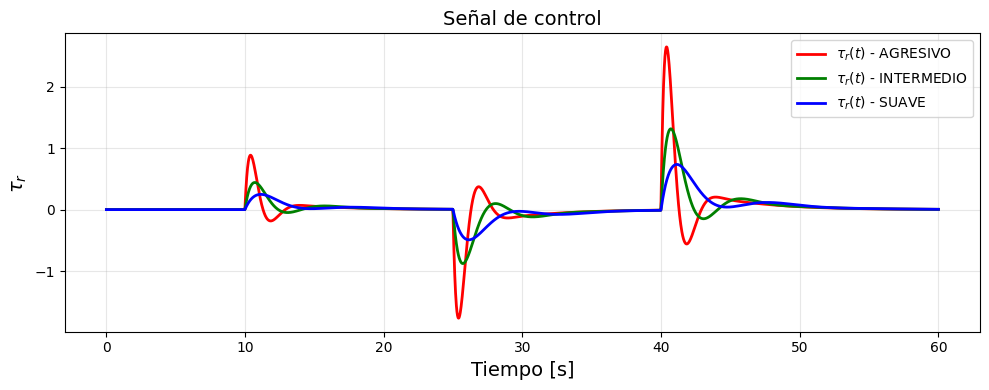

In [87]:
plot_results(results, show=True, save=True, save_dir='plots')

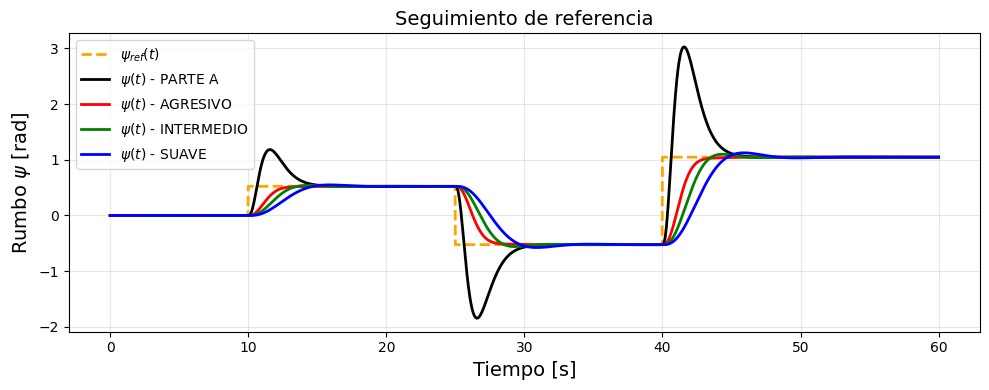

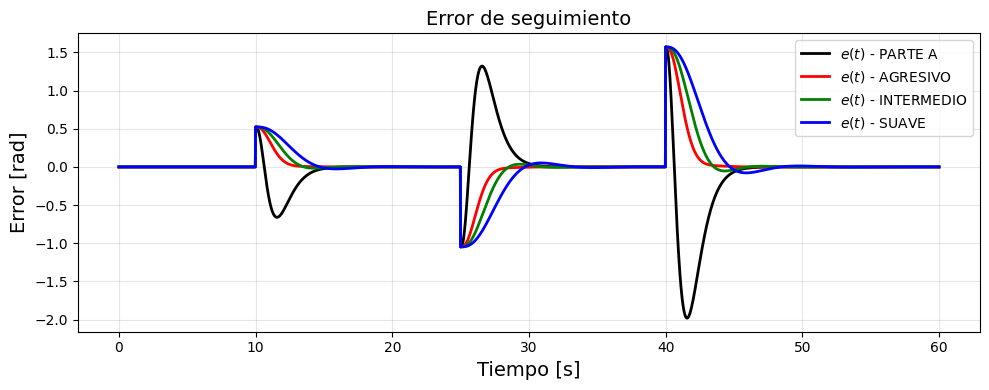

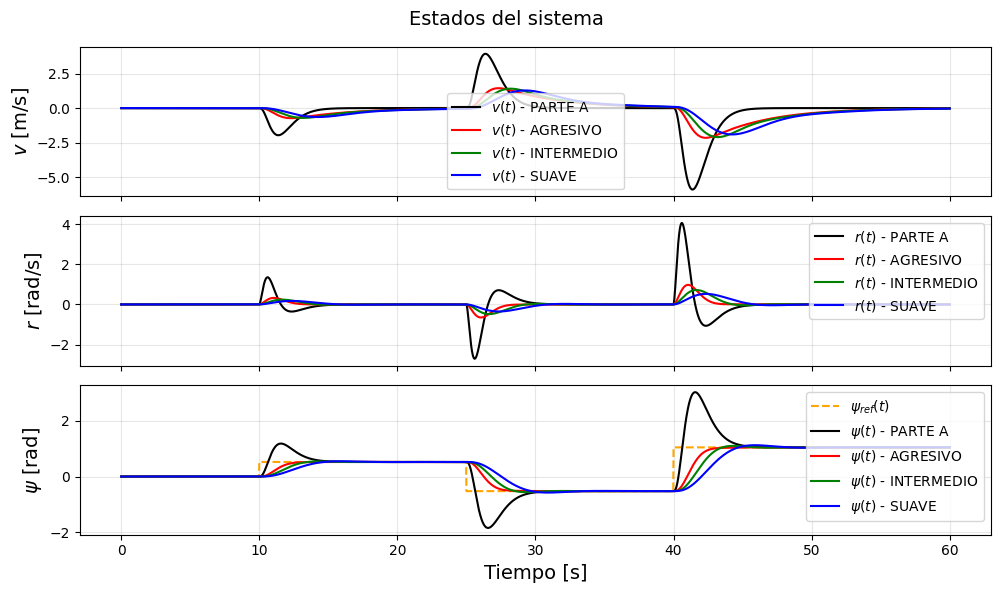

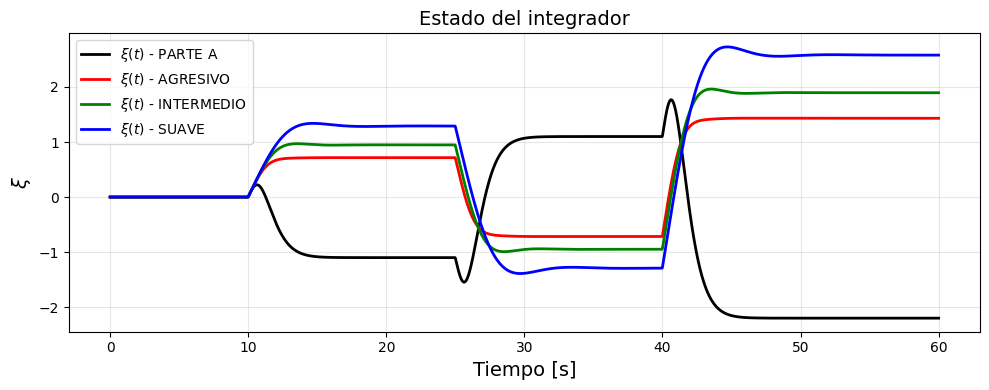

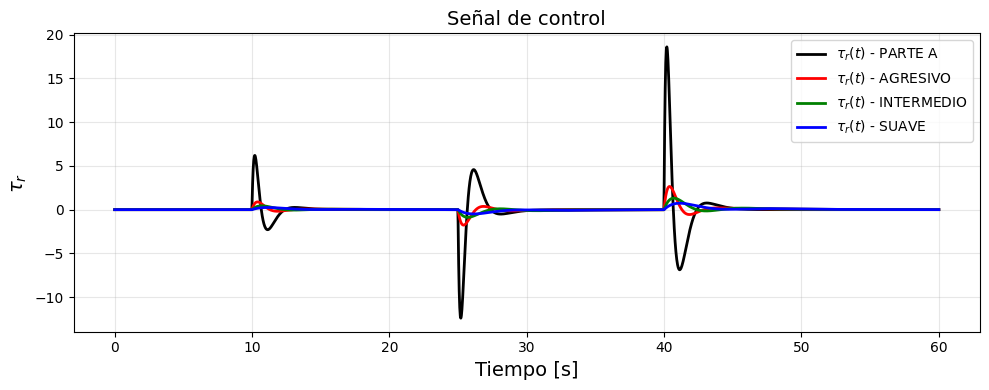

In [88]:
results_comparacion = {"PARTE A": result_A, **results}
plot_results(results_comparacion, show=True, save=True, save_dir='plots')

In [89]:
print_metrics(results_comparacion)

,Controller,Max |tau_r|,RMS tau_r,Max |error|,IAE,ISE,Final error,Max |v|,Max |r|,Max |psi|
0,PARTE A,18.5989,1.9077,1.9810,9.2710,9.8294,-0.0000,5.8903,4.0537,3.0282
1,AGRESIVO,2.646776805399318,0.3396847286317825,1.570840280798321,4.3005536939967515,3.76563740394767,-0.0000,2.150256420074968,0.9749218954572983,1.047513114261291
2,INTERMEDIO,1.3142144937458902,0.2216548040284186,1.5708873601530078,6.013022749802882,5.41647370444199,-0.0000,2.0991414199072156,0.7184772709964348,1.1004181820461965
3,SUAVE,0.7349084088120915,0.16034772749603557,1.5720319300911076,8.448456207420856,7.554348456883359,-0.0001,1.9057967387032266,0.5258611745826137,1.1255242006530115


### 6)

Usamos el intermedio

In [ ]:
u0 = 2.0

result_C = results["INTERMEDIO"]

T_C = result_C["T"]
v_C = result_C["v"]
psi_C = result_C["psi"]

v_interp_C = interp1d(T_C, v_C, kind="linear")
psi_interp_C = interp1d(T_C, psi_C, kind="linear")

def cinematica_C(t, state):
    v_t = float(v_interp_C(t))
    psi_t = float(psi_interp_C(t))

    dX = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
    dY = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)

    return [dX, dY]

sol_C = solve_ivp( cinematica_C, [T_C[0], T_C[-1]], [0.0, 0.0], t_eval=T_C)

X_C = sol_C.y[0]
Y_C = sol_C.y[1]

print("Posición inicial Parte C:")
print("X_C(0) =", X_C[0])
print("Y_C(0) =", Y_C[0])

print("Posición final Parte C:")
print("X_C(Tf) =", round(X_C[-1], 4))
print("Y_C(Tf) =", round(Y_C[-1], 4))

Posición inicial Parte C:
X_C(0) = 0.0
Y_C(0) = 0.0
Posición final Parte C:
X_C(Tf) = 109.1283
Y_C(Tf) = 29.3909


### 7)

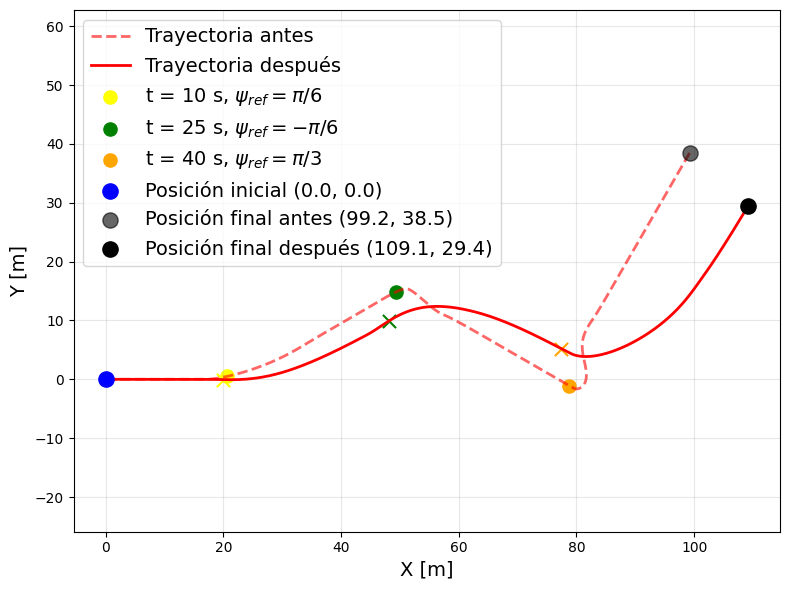

In [102]:
fontsize = 14

idx_10 = np.argmin(np.abs(T - 10))
idx_25 = np.argmin(np.abs(T - 25))
idx_40 = np.argmin(np.abs(T - 40))


plt.figure(figsize=(8, 6))
plt.plot(X_B, Y_B, color='red', linestyle='--', linewidth=2, label='Trayectoria antes', alpha=0.6)
plt.plot(X_C, Y_C, color='red', linewidth=2, label='Trayectoria después')


colors = ['yellow', 'green', 'orange']
plt.scatter(X_B[idx_10], Y_B[idx_10], s=90, label=r"t = 10 s, $\psi_{ref}=\pi/6$", marker='o', color=colors[0])
plt.scatter(X_B[idx_25], Y_B[idx_25], s=90, label=r"t = 25 s, $\psi_{ref}=-\pi/6$", marker='o', color=colors[1])
plt.scatter(X_B[idx_40], Y_B[idx_40], s=90, label=r"t = 40 s, $\psi_{ref}=\pi/3$", marker='o', color=colors[2])

plt.scatter(X_C[idx_10], Y_C[idx_10], s=90, color=colors[0], marker='x')
plt.scatter(X_C[idx_25], Y_C[idx_25], s=90, color=colors[1], marker='x')
plt.scatter(X_C[idx_40], Y_C[idx_40], s=90, color=colors[2], marker='x')


plt.scatter(X_B[0], Y_B[0], color='blue', s=120, label=f'Posición inicial ({X_B[0]:.1f}, {Y_B[0]:.1f})', zorder=3)
plt.scatter(X_B[-1], Y_B[-1], color='black', s=120, label=f'Posición final antes ({X_B[-1]:.1f}, {Y_B[-1]:.1f})', zorder=3, alpha=0.6)
plt.scatter(X_C[-1], Y_C[-1], color='black', s=120, label=f'Posición final después ({X_C[-1]:.1f}, {Y_C[-1]:.1f})', zorder=3)
plt.xlabel('X [m]', fontsize=fontsize)
plt.ylabel('Y [m]', fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(fontsize=fontsize)
plt.tight_layout()
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig("plots/parteC_trayectoria.png", dpi=300)
plt.show()